<a href="https://colab.research.google.com/github/sharoncastillo-coder/Proyecto-Analisis-estadistico-sobre-las-denuncias-del-hurto-en-Colombia/blob/main/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import numpy as np
import geopandas as gpd
import libpysal
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
#cargue informacion
delitos = pd.read_csv('/content/drive/MyDrive/proyecto/Conteo_de_Procesos_V2_20251021.csv')
delitos.head()

/tmp/ipython-input-4221681688.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  delitos = pd.read_csv('/content/drive/MyDrive/proyecto/Conteo_de_Procesos_V2_20251021.csv')


,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS
0,SI,NO,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Atlántico,BARRANQUILLA,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2013,2013,2013,HURTO CALIFICADO ART. 240 C.P. MENOR CUANTIA,HURTO,NO APLICA,233
1,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Nariño,PASTO,DIRECCIÓN SECCIONAL DE NARIÑO,2014,2014,2014,LESIONES ART. 111 C.P.,LESIONES PERSONALES,NO APLICA,1155
2,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Tolima,IBAGUÉ,DIRECCIÓN SECCIONAL DE TOLIMA,2019,2019,2019,HURTO CALIFICADO. ART. 240 C.P.,HURTO,NO APLICA,502
3,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Valle del Cauca,BUENAVENTURA,DIRECCIÓN SECCIONAL DE VALLE DEL CAUCA,2017,2017,2017,HURTO. ART. 239 C.P.,HURTO,NO APLICA,501
4,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Valle del Cauca,CALI,DIRECCIÓN SECCIONAL DE CALI,2014,2014,2014,HURTO. ART. 239 C.P.,HURTO,NO APLICA,1957


In [83]:
#verificar duplicados
delitos[delitos.duplicated()]

,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS


In [84]:
# eliminar variables no necesarias
delitos = delitos.drop(['CRIMINALIDAD', 'LEY', 'PAÍS_HECHO','SECCIONAL', 'AÑO_ENTRADA','CONSUMADO','DELITO'], axis=1)
delitos.head()

,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,AÑO_HECHOS,AÑO_DENUNCIA,GRUPO_DELITO,TOTAL_PROCESOS
0,NO,NO,INACTIVO,INDAGACIÓN,Atlántico,BARRANQUILLA,2013,2013,HURTO,233
1,SI,NO,INACTIVO,INDAGACIÓN,Nariño,PASTO,2014,2014,LESIONES PERSONALES,1155
2,SI,NO,INACTIVO,INDAGACIÓN,Tolima,IBAGUÉ,2019,2019,HURTO,502
3,SI,NO,INACTIVO,INDAGACIÓN,Valle del Cauca,BUENAVENTURA,2017,2017,HURTO,501
4,SI,NO,INACTIVO,INDAGACIÓN,Valle del Cauca,CALI,2014,2014,HURTO,1957


In [85]:
#limpieza datos (cambiar tipo de datos,poner mayusculas, reemplazar caracteres especiales y quitar espacios)
columnas_texto = ['ES_ARCHIVO','ES_PRECLUSIÓN', 'ETAPA_CASO', 'DEPARTAMENTO_HECHO', 'MUNICIPIO_HECHO','GRUPO_DELITO']
delitos[columnas_texto] = delitos[columnas_texto].apply(lambda transf : transf
                                                    .str.strip()
                                                    .str.upper()
                                                    .replace({
                                                        'Á': 'A',
                                                        'É': 'E',
                                                        'Í': 'I',
                                                        'Ó': 'O',
                                                        'Ú': 'U',
                                                        'Ü': 'U',
                                                        'Ñ': 'N',
                                                        '\\.': '',
                                                        '\\. ': '',
                                                        ',': ''}, regex=True)
                                                    .str.replace(r'\s+', ' ', regex=True)
                                                   )
delitos['DEPARTAMENTO_HECHO']= delitos['DEPARTAMENTO_HECHO'].replace('BOGOTA D C', 'BOGOTA DC')
delitos['AÑO_DENUNCIA'] = pd.to_numeric(delitos['AÑO_DENUNCIA'], errors='coerce').astype('Int64')

In [86]:
#filtrar la información que se necesita
hurto = delitos.loc[(delitos['GRUPO_DELITO']=='HURTO') & (delitos['AÑO_HECHOS'] >= 2022) & (delitos['AÑO_HECHOS'] <= 2024)]
hurto

,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,AÑO_HECHOS,AÑO_DENUNCIA,GRUPO_DELITO,TOTAL_PROCESOS
28,SI,NO,INACTIVO,INDAGACION,ATLANTICO,SOLEDAD,2022,2022,HURTO,157
46,SI,NO,INACTIVO,INDAGACION,MAGDALENA,SANTA MARTA,2022,2022,HURTO,118
51,SI,NO,INACTIVO,INDAGACION,CORDOBA,CERETE,2023,2023,HURTO,22
91,SI,NO,INACTIVO,INDAGACION,CAUCA,POPAYAN,2022,2022,HURTO,1187
127,SI,NO,INACTIVO,INDAGACION,CESAR,VALLEDUPAR,2022,2022,HURTO,685
...,...,...,...,...,...,...,...,...,...,...
3176327,NO,NO,INACTIVO,INDAGACION,CUNDINAMARCA,SUBACHOQUE,2023,2024,HURTO,1
3176329,NO,NO,ACTIVO,INDAGACION,SUCRE,CAIMITO,2024,2024,HURTO,1
3176416,SI,NO,INACTIVO,INDAGACION,SANTANDER,EL PLAYON,2023,2023,HURTO,1
3176428,NO,NO,INACTIVO,INDAGACION,SANTANDER,BUCARAMANGA,2023,2024,HURTO,1


In [87]:
#Mirar como aparecen los nulos en los departamentos
pd.concat([
    hurto['DEPARTAMENTO_HECHO'].value_counts(),
    hurto['DEPARTAMENTO_HECHO'].value_counts(normalize=True)
], axis=1)

,count,proportion
DEPARTAMENTO_HECHO,,
ANTIOQUIA,12329,0.125975
CUNDINAMARCA,9401,0.096057
VALLE DEL CAUCA,7294,0.074528
TOLIMA,6372,0.065107
SANTANDER,5363,0.054798
ATLANTICO,4182,0.042731
CAUCA,4180,0.042710
BOYACA,4060,0.041484
HUILA,3874,0.039584


In [88]:
#mirar datos nulos o faltantes
print(hurto.isnull().sum())

#total de procesos sin datos por varibles categoricas
sin_dato_departamento = hurto.loc[hurto['DEPARTAMENTO_HECHO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_municipio = hurto.loc[hurto['MUNICIPIO_HECHO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_archivo = hurto.loc[hurto['ES_ARCHIVO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_preclusion = hurto.loc[hurto['ES_PRECLUSIÓN'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_estado = hurto.loc[hurto['ESTADO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_etapa = hurto.loc[hurto['ETAPA_CASO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()

#TOTAL_PROCESOS
TOTAL_PROCESOS = delitos['TOTAL_PROCESOS'].sum()

# Porcentaje de nulos
porcentaje_sin_dato_dep = (sin_dato_departamento / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_mun = (sin_dato_municipio / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_arc = (sin_dato_archivo / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_pre = (sin_dato_preclusion / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_est = (sin_dato_estado / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_eta = (sin_dato_etapa / TOTAL_PROCESOS) * 100

print(porcentaje_sin_dato_dep)
print(porcentaje_sin_dato_mun)
print(porcentaje_sin_dato_arc)
print(porcentaje_sin_dato_pre)
print(porcentaje_sin_dato_est)
print(porcentaje_sin_dato_eta)

ES_ARCHIVO             0
ES_PRECLUSIÓN          0
ESTADO                 0
ETAPA_CASO             0
DEPARTAMENTO_HECHO     0
MUNICIPIO_HECHO        0
AÑO_HECHOS             0
AÑO_DENUNCIA          36
GRUPO_DELITO           0
TOTAL_PROCESOS         0
dtype: int64
0.0002671942675298073
0.0002671942675298073
0.0
0.0
0.0
2.8125712371558663e-05


In [89]:
#eliminar registros sin información de departamentos
hurto = hurto.drop(hurto[hurto['DEPARTAMENTO_HECHO'] == 'SIN DATO'].index)
hurto = hurto.drop(hurto[hurto['MUNICIPIO_HECHO'] == 'SIN DATO'].index)
hurto = hurto.drop(hurto[hurto['ETAPA_CASO'] == 'SIN DATO'].index)

In [90]:
#validar nuevamente datos nulos o faltantes
print(hurto.isnull().sum())

#total de procesos sin datos por varibles categoricas
sin_dato_departamento = hurto.loc[hurto['DEPARTAMENTO_HECHO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_municipio = hurto.loc[hurto['MUNICIPIO_HECHO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_archivo = hurto.loc[hurto['ES_ARCHIVO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_preclusion = hurto.loc[hurto['ES_PRECLUSIÓN'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_estado = hurto.loc[hurto['ESTADO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()
sin_dato_etapa = hurto.loc[hurto['ETAPA_CASO'] == 'SIN DATO', 'TOTAL_PROCESOS'].sum()

#TOTAL_PROCESOS
TOTAL_PROCESOS = delitos['TOTAL_PROCESOS'].sum()

# Porcentaje de nulos
porcentaje_sin_dato_dep = (sin_dato_departamento / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_mun = (sin_dato_municipio / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_arc = (sin_dato_archivo / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_pre = (sin_dato_preclusion / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_est = (sin_dato_estado / TOTAL_PROCESOS) * 100
porcentaje_sin_dato_eta = (sin_dato_etapa / TOTAL_PROCESOS) * 100

print(porcentaje_sin_dato_dep)
print(porcentaje_sin_dato_mun)
print(porcentaje_sin_dato_arc)
print(porcentaje_sin_dato_pre)
print(porcentaje_sin_dato_est)
print(porcentaje_sin_dato_eta)

ES_ARCHIVO            0
ES_PRECLUSIÓN         0
ESTADO                0
ETAPA_CASO            0
DEPARTAMENTO_HECHO    0
MUNICIPIO_HECHO       0
AÑO_HECHOS            0
AÑO_DENUNCIA          0
GRUPO_DELITO          0
TOTAL_PROCESOS        0
dtype: int64
0.0
0.0
0.0
0.0
0.0
0.0


In [91]:
#Mirar si es necesario agrupar datos
hurto.duplicated(
    subset=[
        'ES_ARCHIVO','ES_PRECLUSIÓN','ESTADO','ETAPA_CASO',
        'DEPARTAMENTO_HECHO','MUNICIPIO_HECHO',
        'AÑO_HECHOS','AÑO_DENUNCIA','GRUPO_DELITO'
    ]
).sum()

np.int64(79216)

In [92]:
#Agrupar datos
hurto = hurto.groupby(
        ['ES_ARCHIVO',
        'ES_PRECLUSIÓN',
        'ESTADO',
        'ETAPA_CASO',
        'DEPARTAMENTO_HECHO',
        'MUNICIPIO_HECHO',
        'AÑO_HECHOS',
        'AÑO_DENUNCIA',
        'GRUPO_DELITO']
        )['TOTAL_PROCESOS'].sum().reset_index()

In [93]:
hurto['TOTAL_PROCESOS'].sum()

np.int64(1620363)

In [94]:
#importar base población municipal

from google.colab import drive
drive.mount('/content/drive')
poblacion_mun = pd.read_excel('/content/drive/MyDrive/proyecto/Población municipal.xlsx',  dtype={'COD_DEP': str,'COD_MUN' :str})
poblacion_mun.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,COD_DEP,DEPARTAMENTO,COD_MUN,MUNICIPIO,AÑO,TOTAL
0,05,ANTIOQUIA,05001,MEDELLIN,2022,2514709
1,05,ANTIOQUIA,05002,ABEJORRAL,2022,21000
2,05,ANTIOQUIA,05004,ABRIAQUI,2022,2792
3,05,ANTIOQUIA,05021,ALEJANDRIA,2022,5042
4,05,ANTIOQUIA,05030,AMAGA,2022,31974


In [95]:
poblacion_mun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3369 entries, 0 to 3368
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   COD_DEP       3369 non-null   object
 1   DEPARTAMENTO  3369 non-null   object
 2   COD_MUN       3369 non-null   object
 3   MUNICIPIO     3369 non-null   object
 4   AÑO           3369 non-null   int64 
 5   TOTAL         3369 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 158.1+ KB


In [96]:
poblacion_mun.rename(columns={
    'TOTAL': 'TOTAL_POBLACION'
}, inplace=True)

In [97]:
#Unir las bases
hurto = pd.merge(
    hurto,
    poblacion_mun,
    how='left',
    left_on=['DEPARTAMENTO_HECHO', 'MUNICIPIO_HECHO','AÑO_HECHOS'],
    right_on=['DEPARTAMENTO', 'MUNICIPIO','AÑO']
)

In [98]:
#Creacion columna de tasa hurtos por 100.000 habitantes
hurto['TASA_HURTO'] = ((hurto['TOTAL_PROCESOS'] / hurto['TOTAL_POBLACION']) * 100000).round(2)
hurto.head()

,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,AÑO_HECHOS,AÑO_DENUNCIA,GRUPO_DELITO,TOTAL_PROCESOS,COD_DEP,DEPARTAMENTO,COD_MUN,MUNICIPIO,AÑO,TOTAL_POBLACION,TASA_HURTO
0,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,BELLO,2024,2024,HURTO,2,05,ANTIOQUIA,05088,BELLO,2024,593344,0.34
1,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,CALDAS,2024,2024,HURTO,1,05,ANTIOQUIA,05129,CALDAS,2024,88316,1.13
2,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,CAUCASIA,2024,2024,HURTO,1,05,ANTIOQUIA,05154,CAUCASIA,2024,93572,1.07
3,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,COPACABANA,2022,2022,HURTO,3,05,ANTIOQUIA,05212,COPACABANA,2022,86835,3.45
4,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,COPACABANA,2024,2024,HURTO,1,05,ANTIOQUIA,05212,COPACABANA,2024,89546,1.12


In [99]:
#Eliminar columnas duplicadas
hurto = hurto.drop(['AÑO', 'MUNICIPIO', 'DEPARTAMENTO'], axis=1)
hurto.head()

,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,AÑO_HECHOS,AÑO_DENUNCIA,GRUPO_DELITO,TOTAL_PROCESOS,COD_DEP,COD_MUN,TOTAL_POBLACION,TASA_HURTO
0,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,BELLO,2024,2024,HURTO,2,05,05088,593344,0.34
1,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,CALDAS,2024,2024,HURTO,1,05,05129,88316,1.13
2,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,CAUCASIA,2024,2024,HURTO,1,05,05154,93572,1.07
3,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,COPACABANA,2022,2022,HURTO,3,05,05212,86835,3.45
4,NO,NO,ACTIVO,EJECUCION DE PENAS,ANTIOQUIA,COPACABANA,2024,2024,HURTO,1,05,05212,89546,1.12


In [100]:
#snake_case para los nombres de columnas
hurto.columns = hurto.columns.str.lower().str.replace(' ', '_')

In [101]:
#exportar archivo
hurto.to_csv('/content/drive/MyDrive/proyecto/hurto.csv', sep='|', index=False, encoding='utf-8')


***Variación tasa de hurto***

In [102]:
#Calcular la varación tasa de hurto general por año

tasa_hurto_año = hurto.groupby('año_hechos').apply(lambda x: (x['total_procesos'].sum() / x['total_poblacion'].sum()) * 100000).reset_index()
tasa_hurto_año.columns = ['año_hechos', 'Tasa_hurto']

#Calcular la variación entre años
tasa_hurto_año['Variacion_anual_%'] = tasa_hurto_año['Tasa_hurto'].pct_change() * 100

#Calcular el coeficiente de variación
cv = hurto.groupby('año_hechos')['tasa_hurto'].apply(lambda x: (x.std() / x.mean()) * 100).reset_index()
cv.columns = ['año_hechos', 'cv']
#unir las bases

tasa_hurto_año = tasa_hurto_año.merge(cv, on='año_hechos')
tasa_hurto_año

/tmp/ipython-input-2728951346.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tasa_hurto_año = hurto.groupby('año_hechos').apply(lambda x: (x['total_procesos'].sum() / x['total_poblacion'].sum()) * 100000).reset_index()


,año_hechos,Tasa_hurto,Variacion_anual_%,cv
0,2022,60.466951,NaN,236.342769
1,2023,77.689055,28.481845,231.704897
2,2024,81.737516,5.211109,194.005415


***Correlación de Pearson***

In [103]:
# Correlación de Pearson por cada año
correlacion_anual = hurto.groupby('año_hechos').apply(
    lambda x: x['total_poblacion'].corr(x['tasa_hurto'])
).reset_index(name='c_pearson')
correlacion_anual

/tmp/ipython-input-2451217113.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlacion_anual = hurto.groupby('año_hechos').apply(


,año_hechos,c_pearson
0,2022,0.006344
1,2023,0.023793
2,2024,0.037728


In [104]:
#Exportar la variación y el coeficiente para mostrar en el tablero
tabla_c_v = tasa_hurto_año.merge(correlacion_anual, on='año_hechos')
tabla_c_v.to_csv('/content/drive/MyDrive/proyecto/tabla_c_v.csv', index=False, sep='|', encoding='utf-8')

***Análisis índice de Moran global***


In [105]:
#Variables de hurto necesarias
hurto_indice = hurto[['departamento_hecho',	'municipio_hecho',	'año_hechos','cod_dep',	'cod_mun','total_procesos', 'total_poblacion']]

In [106]:
#base con la geometria por municipio
municipios = gpd.read_file(
    "/content/drive/MyDrive/proyecto/MGN_ADM_MPIO_GRAFICO.shp")
municipios = municipios[['dpto_ccdgo', 'mpio_cdpmp', 'geometry']]
municipios.head()

,dpto_ccdgo,mpio_cdpmp,geometry
0,05,05001,"POLYGON ((-75.66974 6.3736, -75.66965 6.3736, ..."
1,05,05002,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,05004,"POLYGON ((-76.08351 6.7505, -76.08325 6.75048,..."
3,05,05021,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,..."
4,05,05030,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,..."


In [107]:
#Agrupar datos dado que ya no se usan varias variables de la base de hurto
hurto_indice = hurto_indice.groupby(
        ['departamento_hecho',
        'municipio_hecho',
        'año_hechos',
        'cod_dep',
        'cod_mun',
        'total_poblacion']
        )['total_procesos'].sum().reset_index()

In [108]:
#Recalcular la tasa de hurto
hurto_indice['tasa_hurto'] = ((hurto_indice['total_procesos'] / hurto_indice['total_poblacion']) * 100000).round(2)
hurto_indice.head()

,departamento_hecho,municipio_hecho,año_hechos,cod_dep,cod_mun,total_poblacion,total_procesos,tasa_hurto
0,AMAZONAS,EL ENCANTO,2022,91,91263,2178,2,91.83
1,AMAZONAS,EL ENCANTO,2024,91,91263,2211,1,45.23
2,AMAZONAS,LA CHORRERA,2023,91,91405,3107,1,32.19
3,AMAZONAS,LA CHORRERA,2024,91,91405,3127,1,31.98
4,AMAZONAS,LA PEDRERA,2023,91,91407,4049,2,49.39


In [109]:
hurto_indice['cod_dep'] = hurto_indice['cod_dep'].astype(str)
hurto_indice['cod_mun'] = hurto_indice['cod_mun'].astype(str)
georreferencia = pd.merge(
    hurto_indice,
    municipios,
    how='left',
    left_on=['cod_dep', 'cod_mun'],
    right_on=['dpto_ccdgo', 'mpio_cdpmp']
)

In [110]:
#Eliminar columnas duplicadas
georreferencia = georreferencia.drop(['dpto_ccdgo', 'mpio_cdpmp'], axis=1)

In [111]:
#Grantizar que la base se lea como GeoDataFrame
georreferencia = gpd.GeoDataFrame(georreferencia, geometry='geometry')

In [112]:
#verificar nulos y duplicados
print(georreferencia['geometry'].isna().sum())
print(georreferencia['tasa_hurto'].isna().sum())
print(georreferencia.duplicated(subset=['cod_dep', 'cod_mun','año_hechos']).sum())

0
0
0


In [113]:
# validar si hay municipios sin vecinos

georreferencia_2024_p = georreferencia[georreferencia['año_hechos'] == 2024].copy

w = libpysal.weights.Queen.from_dataframe(georreferencia)

islas = w.islands
print(f"Número de {islas}")

if len(islas) > 0:
    print(f"Índices de las islas: {islas}")
    print(georreferencia_2024_p.iloc[islas][['municipio_hecho', 'departamento_hecho']])

/tmp/ipython-input-3473589400.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(georreferencia)


Número de []


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [114]:
#validar sistema de referencia de coordenadas #medir las coordenadas en metro para la metrica de KNN

print(georreferencia.crs)
georreferencia = georreferencia.to_crs(epsg=3116)
print(georreferencia.crs)

EPSG:4686
EPSG:3116


In [115]:
#Matriz de pesos espaciales KNN año 2022
georreferencia_2022 = georreferencia[georreferencia['año_hechos'] == 2022].copy()

w = libpysal.weights.KNN.from_dataframe(georreferencia_2022, k=5)

w.transform = 'R' #estandarizar peso

islas = w.islands

print(f"número de islas {islas}")

número de islas []


In [116]:
#Indice Moran Global año 2022
y = georreferencia_2022['tasa_hurto'].values
moran = Moran(y, w, permutations=9999)

indice_I =moran.I
P_valor = moran.p_sim
z_score = moran.z_sim

print(f"El estadístico I : {indice_I}")
print(f"p-valor : {P_valor}")
print(f"Z-score : {z_score}")

El estadístico I : 0.4454230276389169
p-valor : 0.0001
Z-score : 25.064988968966762


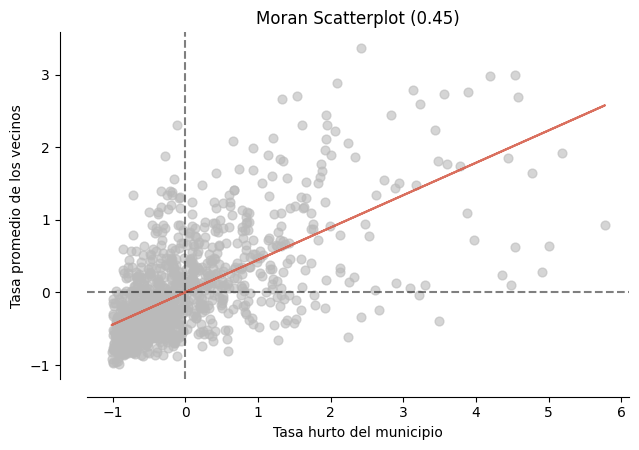

In [117]:
fig, ax = moran_scatterplot(moran, zstandard=True)

ax.set_xlabel('Tasa hurto del municipio')
ax.set_ylabel('Tasa promedio de los vecinos')
plt.show()

In [118]:
#Indice Moran local (lisa) año 2022
np.random.seed(12345)
lisa = Moran_Local(y, w, permutations=9999)

georreferencia_2022['lisa_I'] = lisa.Is
georreferencia_2022['p_valor'] = lisa.p_sim
georreferencia_2022['q'] = lisa.q
georreferencia_2022['z_score_local'] = lisa.z_sim

In [119]:
cluster_nom = {1: 'Hotspot (Alta-Alta)', 2: 'Outlier (Baja-Alta)', 3: 'Coldspot (Baja-Baja)', 4: 'Outlier (Alta-Baja)'}

In [120]:
georreferencia_2022['cluster'] = georreferencia_2022.apply(
    lambda row: cluster_nom[row['q']] if row['p_valor'] <= 0.05 else 'No significativo',
    axis=1
)

In [121]:
georreferencia_2022['cluster'].value_counts()

,count
cluster,
No significativo,784
Coldspot (Baja-Baja),180
Hotspot (Alta-Alta),99
Outlier (Baja-Alta),24
Outlier (Alta-Baja),9


In [122]:
#Dato para realizar grafica de dispersion
georreferencia_2022['lag_hurto'] = libpysal.weights.lag_spatial(w, georreferencia_2022['tasa_hurto'])

In [123]:

georreferencia_2022['moran_p_global'] = P_valor
georreferencia_2022['moran_z_global'] = z_score

In [124]:
#Matriz de pesos espaciales KNN año 2023
georreferencia_2023 = georreferencia[georreferencia['año_hechos'] == 2023].copy()

w = libpysal.weights.KNN.from_dataframe(georreferencia_2023, k=5)

w.transform = 'R' #estandarizar peso

islas = w.islands

print(f"número de islas {islas}")

número de islas []


In [125]:
#Indice Moran Global año 2023
y = georreferencia_2023['tasa_hurto'].values
moran = Moran(y, w, permutations=9999)

indice_I =moran.I
P_valor = moran.p_sim
z_score = moran.z_sim

print(f"El estadístico I : {indice_I}")
print(f"p-valor : {P_valor}")
print(f"Z-score : {z_score}")

El estadístico I : 0.44040857370502534
p-valor : 0.0001
Z-score : 24.515302548675663


In [126]:
#Indice Moran local (lisa) año 2023
np.random.seed(12345)
lisa = Moran_Local(y, w, permutations=9999)

georreferencia_2023['lisa_I'] = lisa.Is
georreferencia_2023['p_valor'] = lisa.p_sim
georreferencia_2023['q'] = lisa.q
georreferencia_2023['z_score_local'] = lisa.z_sim

In [127]:
georreferencia_2023['cluster'] = georreferencia_2023.apply(
    lambda row: cluster_nom[row['q']] if row['p_valor'] <= 0.05 else 'No significativo',
    axis=1
)

In [128]:
georreferencia_2023['cluster'].value_counts()

,count
cluster,
No significativo,785
Coldspot (Baja-Baja),185
Hotspot (Alta-Alta),97
Outlier (Baja-Alta),22
Outlier (Alta-Baja),10


In [130]:
georreferencia_2023['lag_hurto'] = libpysal.weights.lag_spatial(w, georreferencia_2023['tasa_hurto'])

In [131]:
#Datos para el tablero
georreferencia_2023['moran_p_global'] = P_valor
georreferencia_2023['moran_z_global'] = z_score

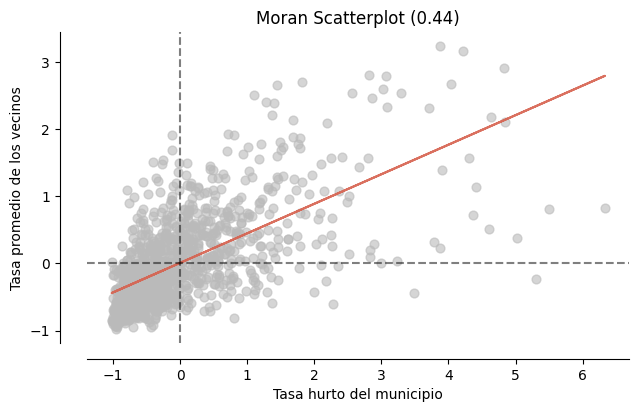

In [132]:
fig, ax = moran_scatterplot(moran, zstandard=True)

ax.set_xlabel('Tasa hurto del municipio')
ax.set_ylabel('Tasa promedio de los vecinos')
plt.show()

In [133]:
#Matriz de pesos espaciales KNN año 2024
georreferencia_2024 = georreferencia[georreferencia['año_hechos'] == 2024].copy()

w = libpysal.weights.KNN.from_dataframe(georreferencia_2024, k=5)

w.transform = 'R' #estandarizar peso

islas = w.islands

print(f"número de islas {islas}")

número de islas []


In [134]:
#Indice Moran Global año 2024
y = georreferencia_2024['tasa_hurto'].values
moran = Moran(y, w, permutations=9999)

indice_I =moran.I
P_valor = moran.p_sim
z_score = moran.z_sim

print(f"El estadístico I : {indice_I}")
print(f"p-valor : {P_valor}")
print(f"Z-score : {z_score}")

El estadístico I : 0.41089811151309
p-valor : 0.0001
Z-score : 22.99263828284172


In [135]:
#Indice Moran local (lisa) año 2024
np.random.seed(12345)
lisa = Moran_Local(y, w, permutations=9999)

georreferencia_2024['lisa_I'] = lisa.Is
georreferencia_2024['p_valor'] = lisa.p_sim
georreferencia_2024['q'] = lisa.q
georreferencia_2024['z_score_local'] = lisa.z_sim

In [136]:
georreferencia_2024['cluster'] = georreferencia_2024.apply(
    lambda row: cluster_nom[row['q']] if row['p_valor'] <= 0.05 else 'No significativo',
    axis=1
)

In [137]:
georreferencia_2024['cluster'].value_counts()

,count
cluster,
No significativo,783
Coldspot (Baja-Baja),174
Hotspot (Alta-Alta),100
Outlier (Baja-Alta),19
Outlier (Alta-Baja),10


In [138]:
georreferencia_2024['lag_hurto'] = libpysal.weights.lag_spatial(w, georreferencia_2024['tasa_hurto'])

In [139]:
#Datos para el tablero
georreferencia_2024['moran_p_global'] = P_valor
georreferencia_2024['moran_z_global'] = z_score

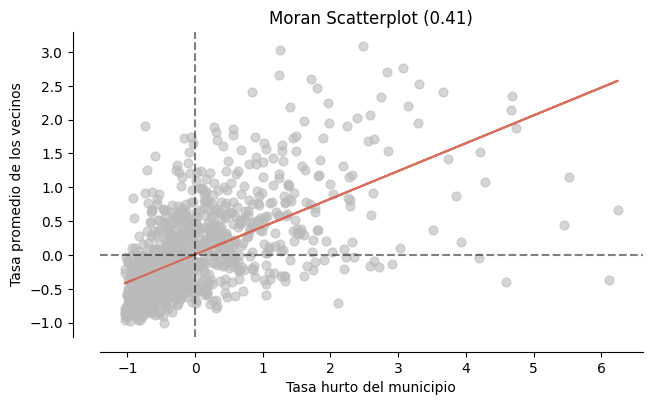

In [140]:
fig, ax = moran_scatterplot(moran, zstandard=True)

ax.set_xlabel('Tasa hurto del municipio')
ax.set_ylabel('Tasa promedio de los vecinos')
plt.show()

In [129]:
LISA_comparativo = pd.DataFrame({
    '2022':georreferencia_2022['cluster'].value_counts(),
    '2023': georreferencia_2023['cluster'].value_counts(),
    '2024': georreferencia_2024['cluster'].value_counts()
})
LISA_comparativo

,2022,2023,2024
cluster,,,
No significativo,784,785,783
Coldspot (Baja-Baja),180,185,174
Hotspot (Alta-Alta),99,97,100
Outlier (Baja-Alta),24,22,19
Outlier (Alta-Baja),9,10,10


In [141]:
#Unir bases para exportar
indice_moran = pd.concat([georreferencia_2022, georreferencia_2023, georreferencia_2024], ignore_index=True)
indice_moran = indice_moran.drop('geometry', axis=1)
indice_moran.head()

,departamento_hecho,municipio_hecho,año_hechos,cod_dep,cod_mun,total_poblacion,total_procesos,tasa_hurto,lisa_I,p_valor,q,z_score_local,cluster,lag_hurto,moran_p_global,moran_z_global
0,AMAZONAS,EL ENCANTO,2022,91,91263,2178,2,91.83,0.502463,0.0202,3,1.487048,Coldspot (Baja-Baja),122.550,0.0001,25.064989
1,AMAZONAS,LETICIA,2022,91,91001,51645,388,751.28,-0.840739,0.0209,4,-1.478799,Outlier (Alta-Baja),123.244,0.0001,25.064989
2,AMAZONAS,PUERTO ARICA,2022,91,91536,1048,1,95.42,0.495191,0.0205,3,1.489033,Coldspot (Baja-Baja),122.526,0.0001,25.064989
3,AMAZONAS,PUERTO NARINO,2022,91,91540,10770,19,176.42,0.159484,0.2535,3,0.723558,No significativo,233.828,0.0001,25.064989
4,AMAZONAS,PUERTO SANTANDER,2022,91,91669,1827,1,54.73,0.673545,0.0031,3,1.733695,Coldspot (Baja-Baja),87.012,0.0001,25.064989


In [142]:
#Verificar los datos despues de la union
indice_moran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3281 entries, 0 to 3280
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento_hecho  3281 non-null   object 
 1   municipio_hecho     3281 non-null   object 
 2   año_hechos          3281 non-null   int64  
 3   cod_dep             3281 non-null   object 
 4   cod_mun             3281 non-null   object 
 5   total_poblacion     3281 non-null   int64  
 6   total_procesos      3281 non-null   int64  
 7   tasa_hurto          3281 non-null   float64
 8   lisa_I              3281 non-null   float64
 9   p_valor             3281 non-null   float64
 10  q                   3281 non-null   int64  
 11  z_score_local       3281 non-null   float64
 12  cluster             3281 non-null   object 
 13  lag_hurto           3281 non-null   float64
 14  moran_p_global      3281 non-null   float64
 15  moran_z_global      3281 non-null   float64
dtypes: flo

In [143]:
#exportar archivo
indice_moran.to_csv('/content/drive/MyDrive/proyecto/indice_moran.csv', sep='|', index=False, encoding='utf-8')

***Matriz de transición***

In [144]:
#Seleccionar columnas necesarias por cada año
df_2022 = georreferencia_2022[['departamento_hecho', 'municipio_hecho','año_hechos','cod_dep','cod_mun','cluster']]
df_2022 = df_2022.rename(columns={'cluster': 'cluster_2022'})

df_2023 = georreferencia_2023[['departamento_hecho', 'municipio_hecho','año_hechos','cod_dep','cod_mun','cluster']]
df_2023 = df_2023.rename(columns={'cluster': 'cluster_2023'})

df_2024 = georreferencia_2024[['departamento_hecho', 'municipio_hecho','año_hechos','cod_dep','cod_mun','cluster']]
df_2024 = df_2024.rename(columns={'cluster': 'cluster_2024'})

In [145]:
#Base para grafico PowerBI
transicion = df_2022.merge(df_2023,
                           on=['cod_dep', 'cod_mun', 'departamento_hecho','municipio_hecho'],
                           how='inner').merge(df_2024,
                                               on=['cod_dep', 'cod_mun', 'departamento_hecho','municipio_hecho'],
                                               how='inner')
transicion = transicion.drop(['año_hechos_x', 'año_hechos_y', 'año_hechos'], axis=1)
transicion

,departamento_hecho,municipio_hecho,cod_dep,cod_mun,cluster_2022,cluster_2023,cluster_2024
0,AMAZONAS,LETICIA,91,91001,Outlier (Alta-Baja),Outlier (Alta-Baja),Outlier (Alta-Baja)
1,AMAZONAS,PUERTO NARINO,91,91540,No significativo,Coldspot (Baja-Baja),No significativo
2,ANTIOQUIA,ABEJORRAL,05,05002,No significativo,No significativo,No significativo
3,ANTIOQUIA,ALEJANDRIA,05,05021,No significativo,No significativo,No significativo
4,ANTIOQUIA,AMAGA,05,05030,No significativo,No significativo,No significativo
...,...,...,...,...,...,...,...
1059,VAUPES,TARAIRA,97,97666,Coldspot (Baja-Baja),No significativo,No significativo
1060,VICHADA,CUMARIBO,99,99773,No significativo,No significativo,No significativo
1061,VICHADA,LA PRIMAVERA,99,99524,No significativo,No significativo,No significativo
1062,VICHADA,PUERTO CARRENO,99,99001,No significativo,No significativo,No significativo


In [146]:
#verificar nulos y duplicados
print(transicion.duplicated(subset=['cod_dep', 'cod_mun']).sum())
print(transicion.isnull().sum())

0
departamento_hecho    0
municipio_hecho       0
cod_dep               0
cod_mun               0
cluster_2022          0
cluster_2023          0
cluster_2024          0
dtype: int64


In [147]:
#Crear funcion para catalogar la transicion

def categoria_transicion(estado):
    inicio = estado["cluster_2022"]
    medio = estado["cluster_2023"]
    final = estado["cluster_2024"]

    # Caso 1: sin cambios
    if inicio == medio == final:
        if inicio == "Hotspot (Alta-Alta)":
            return "Hotspot estable"
        if inicio == "Coldspot (Baja-Baja)":
            return "Coldspot estable"
        if inicio == "No significativo":
            return "No significativo estable"
        return "Outlier estable"

    #Caso 2:Inestabilidad
    if inicio == final:
        return "Inestabilidad temporal"

   #Caso 3: cambio por deterioro
    if final == "Hotspot (Alta-Alta)":
        if inicio == "Outlier (Baja-Alta)": return "Deterioro por contagio"
        return "Deterioro crítico"
    if final == "Outlier (Baja-Alta)" and inicio in ["No significativo", "Coldspot (Baja-Baja)"]:
        return "Tendencia a deteriorar"
    if inicio == "Coldspot (Baja-Baja)" and final != "Coldspot (Baja-Baja)":
        return "Tendencia a deteriorar"
    if final == "Outlier (Alta-Baja)":
        return "Tendencia a deteriorar"


    #Caso 2: Cambio por mejora
    if final == "Coldspot (Baja-Baja)":
        return "Tendencia a mejorar"
    if inicio == "Hotspot (Alta-Alta)" and final != "Hotspot (Alta-Alta)":
        if final == "No significativo":
            return "Desarticulación del foco"
        return "Tendencia a mejorar" # Aquí caen los casos 540 y 652 (de Hot a Outlier)

    if inicio in ["Outlier (Baja-Alta)", "Outlier (Alta-Baja)"] and final == "No significativo":
        return "Tendencia a mejorar"

    return "Transición mixta"


In [148]:
# Aplicar la funcion a la base de transicion
transicion["categoria transicion"] = transicion.apply(categoria_transicion, axis=1)

In [149]:
# Verificar nulos en la nueva variable
print(transicion['categoria transicion'].isnull().sum())

0


In [150]:
total = transicion['categoria transicion'].value_counts()
porcentaje = (transicion['categoria transicion'].value_counts(normalize=True) * 100).round(2)

categorias = pd.DataFrame({
    'total': total,
    'porcentaje (%)': porcentaje
})
categorias

,total,porcentaje (%)
categoria transicion,,
No significativo estable,676,63.53
Coldspot estable,103,9.68
Hotspot estable,75,7.05
Tendencia a mejorar,54,5.08
Tendencia a deteriorar,53,4.98
Inestabilidad temporal,53,4.98
Desarticulación del foco,16,1.50
Outlier estable,14,1.32
Deterioro crítico,14,1.32


In [151]:
#Mirar combinaciones para generar la clasificación
#combinaciones = transicion[~transicion['categoria transicion'].isin(['Hotspot estable', 'Coldspot estable', 'No significativo estable','Outlier estable'])]

# Seleccionar solo las columnas de los años y ver las combinaciones sin repetir
#combinaciones_unicas = combinaciones[['cluster_2022', 'cluster_2023', 'cluster_2024','categoria transicion']].drop_duplicates()
#combinaciones_unicas

In [152]:
#Exportar base de transicion
transicion.to_csv('/content/drive/MyDrive/proyecto/transicion.csv', sep='|', index=False, encoding='utf-8')

In [153]:
#Unir las bases y crear la matriz
matriz_22_23 = pd.merge(df_2022,
                  df_2023,
                  on=['cod_dep', 'cod_mun'])

matriz_22_23 = pd.crosstab(
    matriz_22_23['cluster_2022'],
    matriz_22_23['cluster_2023'],
    normalize='index'
)
matriz_22_23

cluster_2023,Coldspot (Baja-Baja),Hotspot (Alta-Alta),No significativo,Outlier (Alta-Baja),Outlier (Baja-Alta)
cluster_2022,,,,,
Coldspot (Baja-Baja),0.774566,0.000000,0.219653,0.005780,0.000000
Hotspot (Alta-Alta),0.000000,0.858586,0.121212,0.000000,0.020202
No significativo,0.052632,0.008986,0.929397,0.005135,0.003851
Outlier (Alta-Baja),0.222222,0.000000,0.222222,0.555556,0.000000
Outlier (Baja-Alta),0.000000,0.208333,0.083333,0.000000,0.708333


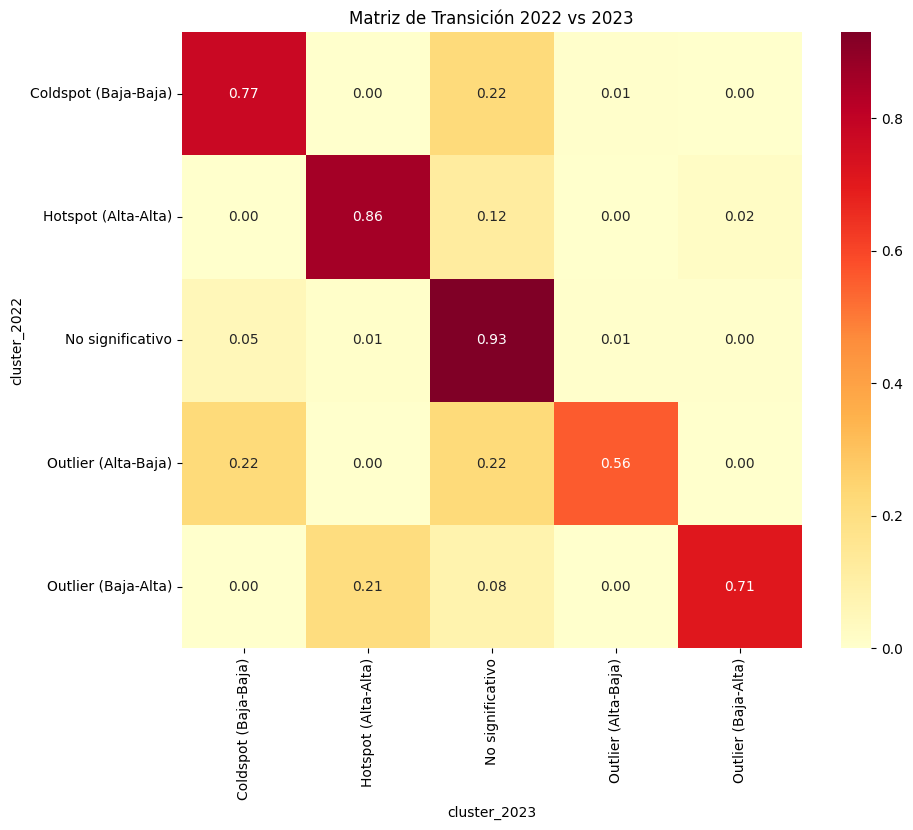

In [154]:
# Mapa de calor 2022 vs 2023

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_22_23, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Matriz de Transición 2022 vs 2023')
plt.show()

In [155]:
#Unir las bases
merged_23_24 = pd.merge(df_2023,
                  df_2024,
                  on=['cod_dep', 'cod_mun'])

matriz_23_24 = pd.crosstab(
    merged_23_24['cluster_2023'],
    merged_23_24['cluster_2024'],
    normalize='index'
)
matriz_23_24

cluster_2024,Coldspot (Baja-Baja),Hotspot (Alta-Alta),No significativo,Outlier (Alta-Baja),Outlier (Baja-Alta)
cluster_2023,,,,,
Coldspot (Baja-Baja),0.739884,0.000000,0.248555,0.011561,0.000000
Hotspot (Alta-Alta),0.000000,0.835052,0.113402,0.000000,0.051546
No significativo,0.050518,0.015544,0.926166,0.003886,0.003886
Outlier (Alta-Baja),0.000000,0.000000,0.500000,0.500000,0.000000
Outlier (Baja-Alta),0.000000,0.318182,0.181818,0.000000,0.500000


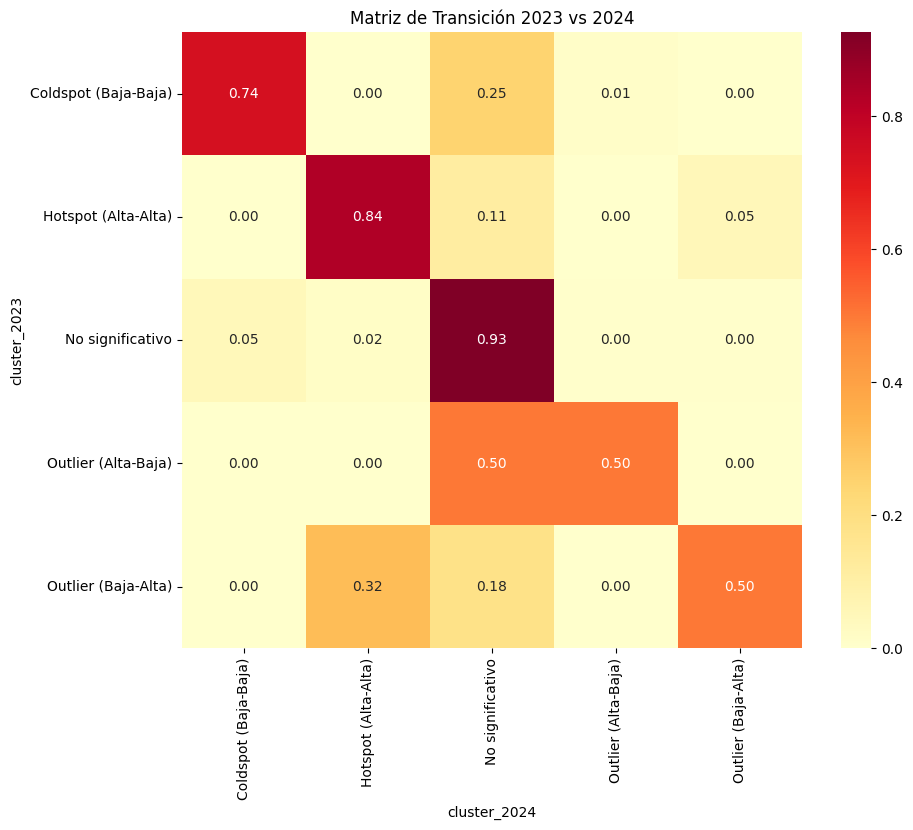

In [156]:
# Mapa de calor 2023 vs 2024

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_23_24, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Matriz de Transición 2023 vs 2024')
plt.show()

In [157]:
#Unir las bases
merged_22_24 = pd.merge(df_2022,
                  df_2024,
                  on=['cod_dep', 'cod_mun'])

matriz_22_24 = pd.crosstab(
    merged_22_24['cluster_2022'],
    merged_22_24['cluster_2024'],
    normalize='index'
)
matriz_22_24

cluster_2024,Coldspot (Baja-Baja),Hotspot (Alta-Alta),No significativo,Outlier (Alta-Baja),Outlier (Baja-Alta)
cluster_2022,,,,,
Coldspot (Baja-Baja),0.712575,0.000000,0.281437,0.005988,0.000000
Hotspot (Alta-Alta),0.000000,0.808081,0.161616,0.000000,0.030303
No significativo,0.056921,0.018111,0.917206,0.003881,0.003881
Outlier (Alta-Baja),0.111111,0.000000,0.222222,0.666667,0.000000
Outlier (Baja-Alta),0.000000,0.250000,0.208333,0.000000,0.541667


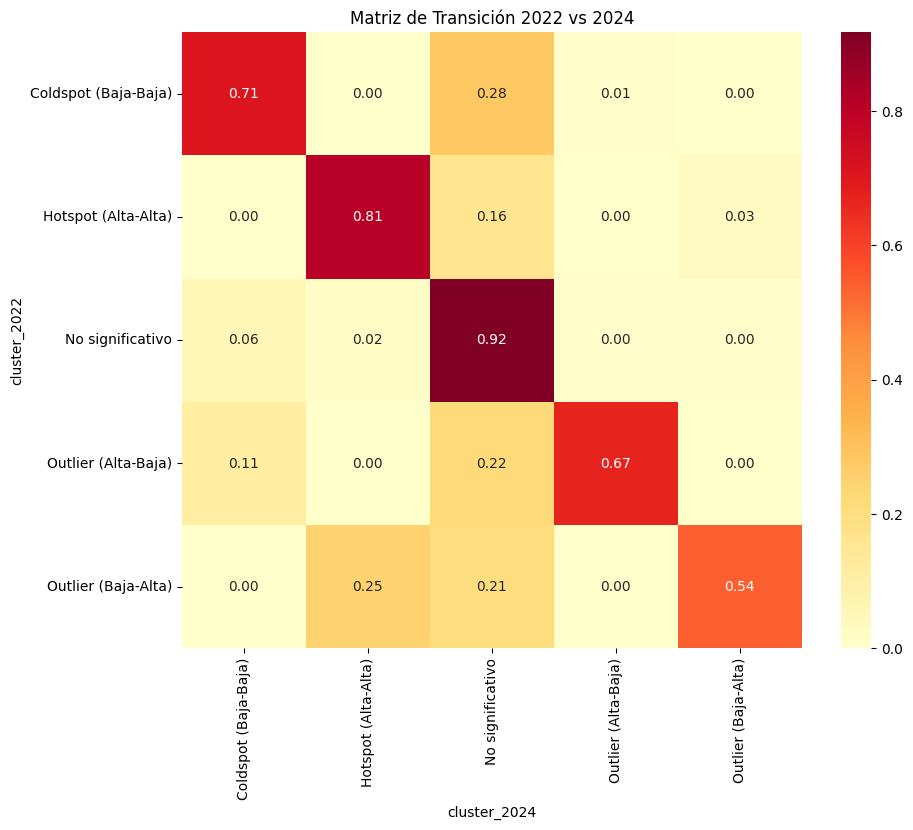

In [158]:
# Mapa de calor 2022 vs 2024

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_22_24, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Matriz de Transición 2022 vs 2024')
plt.show()